In [59]:
import pandas as pd
import datetime as dt
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set(style="darkgrid")

In [60]:
full_datas = {}
folder_path = r'..\data\raw_data'
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
for file_path in csv_files:
    # Получаем имя файла без расширения
    filename = os.path.splitext(os.path.basename(file_path))[0]
    
    # Читаем CSV
    full_datas[filename] = pd.read_csv(file_path)

full_datas.keys()

dict_keys(['acer', 'ageofempires', 'blenderartists', 'brave', 'elastic', 'envato', 'eveonline', 'fatsharkgames', 'figma', 'forums.developer.nvidia.com', 'freecodecamp', 'funcom', 'google', 'infiniteflight', 'ionicframework', 'jitsi', 'manjaro', 'mcneel', 'n8n', 'obsidian', 'openai', 'openhab', 'opensuse', 'openwrt', 'plex', 'python', 'roblox', 'sheknows', 'shopify', 'spiceworks', 'straightdope', 'unity', 'unrealengine', 'warthunder', 'wd', 'wyze'])

In [61]:
for name, data in full_datas.items():
    data.drop(data[data['author_id'] < 0].index, inplace=True)
    data['created_at'] = pd.to_datetime(data['created_at'], format='mixed', errors='coerce')

In [ ]:
def calculate_answer_stats(data, name):
    max_date = data['created_at'].max()
    topics = (
        data[data['post_type'] == 1]
        .groupby('topic_id', as_index=False)['created_at']
        .min().rename(columns={'created_at': 'topic_created_at'})
        )
    replies = (
        data[data['post_type'] == 2]
        .groupby('topic_id', as_index=False)['created_at']
        .min().rename(columns={'created_at': 'first_reply_at'})
        )
    
    stats = pd.merge(
        topics,
        replies,
        on='topic_id',
        how='left'
        )
    
    stats['response_time'] = (stats['first_reply_at'] - stats['topic_created_at']).dt.total_seconds() / 3600

    # удалим топики которые были созданы в конце датасета
    stats['followup_hours'] = (
        max_date - stats['topic_created_at']
        ).dt.total_seconds() / 3600
    
    
    #убирем топики, для которых не прошло 48 часов с момента создания
    stats = stats[stats['followup_hours'] >= 48]

    #Среднее время ответа
    mean_response_time = stats['response_time'].mean()
    #Вероятность получить ответ в целом
    prob_any_reply = round(stats['first_reply_at'].notna().mean() * 100, 2)

    row_results = {
        'dataset': name,
        'MTA': round(mean_response_time, 2),
        'prob_any_reply': prob_any_reply
    }

    thresholds = {10: 'prob_10_reply', 
                  20: 'prob_20_reply', 
                  24: 'prob_24_reply', 
                  48: 'prob_48_reply'}

    # Шанс получить ответ, если не получили в течении hours часов
    for hours, col_name in thresholds.items():
        no_reply_t = stats[stats['response_time'].isna() | (stats['response_time'] > hours)]
        row_results[col_name] = round(no_reply_t['response_time'].notna().mean() * 100, 2)

    return row_results

In [96]:
global_stats = pd.DataFrame()
for name, data in full_datas.items():
    stats_row = calculate_answer_stats(data, name)
    global_stats = pd.concat([global_stats, pd.DataFrame([stats_row])], ignore_index=True)

In [97]:
display(global_stats.head(20))

,dataset,MTA,prob_any_reply,prob_10_reply,prob_20_reply,prob_24_reply,prob_48_reply
0,acer,2.56,90.56,41.84,26.03,22.04,12.35
1,ageofempires,210.80,72.75,44.60,36.91,34.54,27.32
2,blenderartists,53.52,91.20,61.38,47.29,43.40,32.29
3,brave,192.77,70.78,41.90,33.96,31.52,23.52
4,elastic,69.31,78.54,57.56,49.51,46.83,38.52
5,envato,88.95,78.29,42.09,31.25,27.72,18.60
6,eveonline,51.20,83.35,62.89,56.93,53.32,39.15
7,fatsharkgames,55.80,72.97,37.69,27.00,24.23,15.51
8,figma,522.76,69.77,53.50,48.53,46.75,38.23
9,forums.developer.nvidia.com,272.37,86.38,74.81,66.27,63.90,57.10


где, 
- dataset - название датасета
- MTA - среднее время для ответа
- prob_any_reply - просто вероятность, чтоы мы получим ответ впринципе для своего вопроса (потенциально показывает качество сообщества)
- prob_Х_reply - вероятность получить ответ после Х часов

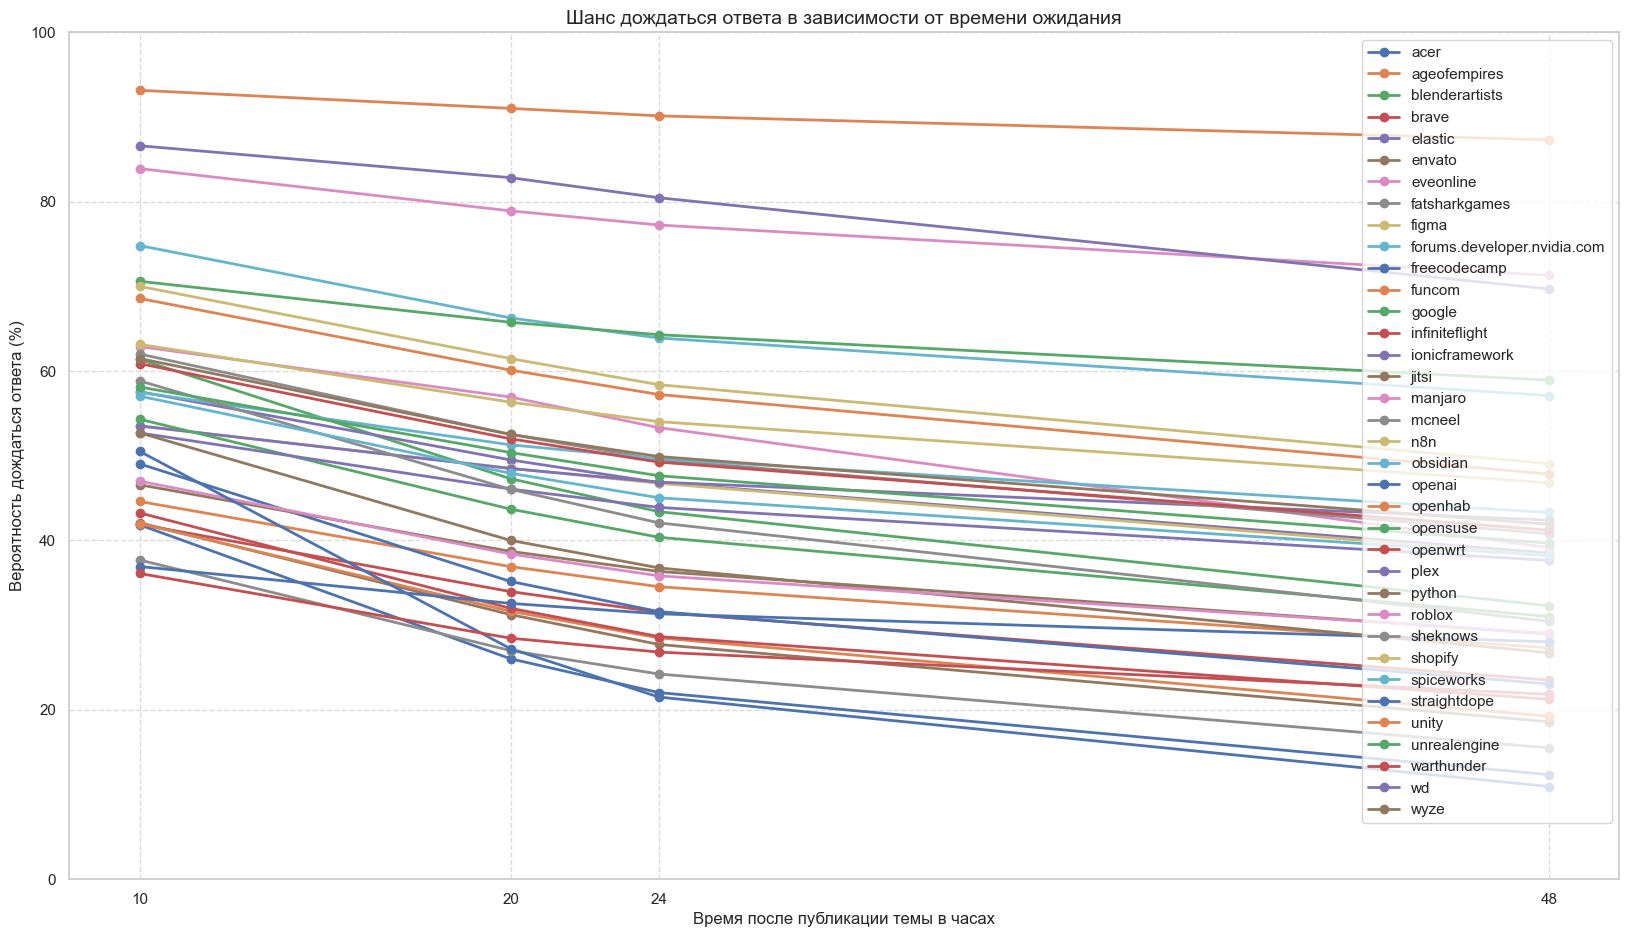

In [112]:
# Красиво выведем результаты в виде графиков для разных датасетов, где на оси y будет вероятность, а на оси х будет время ответа (10, 20, 24, 48 часов)
plt.figure(figsize=(20, 11))
plt.grid(True, linestyle='--', alpha=0.7)

# Список часов для оси X
hours = [10, 20, 24, 48]

# Проходимся по каждой строке в итоговой таблице
for i, row in global_stats.iterrows():
    # Собираем значения вероятностей для текущего датасета
    probs = [row['prob_10_reply'], row['prob_20_reply'], row['prob_24_reply'], row['prob_48_reply']]
    
    # Рисуем линию для этого датасета
    plt.plot(hours, probs, marker='o', label=row['dataset'], linewidth=2)


plt.title('Шанс дождаться ответа в зависимости от времени ожидания', fontsize=14)
plt.xlabel('Время после публикации темы в часах', fontsize=12)
plt.ylabel('Вероятность дождаться ответа (%)', fontsize=12)
plt.xticks(hours) # Чтобы на оси x были только наши цифры
plt.ylim(0, 100)  # Шкала от 0 до 100%
plt.legend(loc='upper right')      # Показывает названия датасетов

plt.show()